# Thesis — Step 2: Prediction Models (revised)

**Question answered here:** how accurately can machine learning predict a household's food consumption group, and which structural characteristics carry the predictive signal?


1. Multicollinearity among the structural predictors is checked **before** any importance is interpreted, since correlated variables distort the attribution of importance.
2. The rule for selecting the variables carried forward to the clustering is **fixed in advance**, not chosen after seeing the results.
3. The middle food consumption category is reported as **Borderline**, the standard WFP term. DIEM labels it Moderate and applies the adjusted thresholds of 28 and 42 rather than the standard 21 and 35, which WFP permits where oil and sugar are consumed very frequently.


## 1. Install the extra libraries

In [1]:
import sys
!{sys.executable} -m pip install xgboost shap --quiet


## 2. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, ConfusionMatrixDisplay)
from scipy.stats import chi2_contingency
from xgboost import XGBClassifier
import shap

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 220)

RANDOM_STATE = 42
CLASSES = ['Poor', 'Borderline', 'Acceptable']
YMAP = {c: i for i, c in enumerate(CLASSES)}
INV = {i: c for c, i in YMAP.items()}
print('ready')

ready


## 3. Load the data

DIEM's label for the middle category is renamed to the standard WFP term. The categories themselves are unchanged.

In [3]:
df = pd.read_csv('clean_R8.csv')
df['fcg'] = df['fcg'].replace({'Moderate': 'Borderline'})

y = df['fcg']
X = df.drop(columns=['fcg', 'weight_final', 'round'])

print('predictors:', X.shape[1], '| households:', len(df))
print(y.value_counts().to_dict())

predictors: 74 | households: 9494
{'Borderline': 4115, 'Poor': 3388, 'Acceptable': 1991}


## 4. Multicollinearity among the structural predictors

This comes before the models because correlated predictors split the credit for the same information between them, which makes any importance ranking unreliable.

Cramer's V measures association between two categorical variables on a scale from 0 to 1. The variance inflation factor does the same job for the numeric ones.

In [4]:
cat_all = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
num_all = [c for c in X.columns if c not in cat_all]

def cramers_v(a, b):
    table = pd.crosstab(a, b)
    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(table)[0]
    n = table.values.sum()
    phi2 = chi2 / n
    r, k = table.shape
    phi2c = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rc = r - ((r - 1) ** 2) / (n - 1)
    kc = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2c / max(1e-12, min(kc - 1, rc - 1)))

pairs = []
for a, b in combinations(cat_all, 2):
    v = cramers_v(X[a], X[b])
    if v == v and v > 0.5:
        pairs.append({'variable A': a, 'variable B': b, "Cramer's V": round(v, 3)})

pairs = pd.DataFrame(pairs).sort_values("Cramer's V", ascending=False)
print('categorical pairs above 0.5:', len(pairs), 'out of', len(cat_all) * (len(cat_all) - 1) // 2)
print(pairs.head(12).to_string(index=False))

categorical pairs above 0.5: 343 out of 2211
         variable A               variable B  Cramer's V
   hh_agricactivity        resp_islsproducer       1.000
   hh_agricactivity      resp_iscropproducer       1.000
  resp_islsproducer                  ls_main       1.000
resp_iscropproducer          crp_area_change       0.994
resp_iscropproducer         crp_irrig_source       0.994
resp_iscropproducer          crp_harv_change       0.994
resp_iscropproducer                 crp_main       0.992
 need_received_food       need_received_none       0.924
       need_ls_feed      need_ls_vet_service       0.822
need_ls_vet_service   need_ls_infrastructure       0.802
   need_crop_inputs need_crop_infrastructure       0.792
 need_received_cash       need_received_none       0.790


In [5]:
print('VARIANCE INFLATION FACTORS, numeric predictors')
for c in num_all:
    others = [o for o in num_all if o != c]
    r2 = LinearRegression().fit(X[others], X[c]).score(X[others], X[c])
    print(f'  {c:28s} {1 / max(1e-9, 1 - r2):.2f}')

VARIANCE INFLATION FACTORS, numeric predictors
  tot_income                   1.07
  crp_landsize_ha              1.05
  ls_num_diff                  1.02
  n_shocks                     1.00
  tot_income_missing           1.04
  crp_landsize_ha_missing      1.09
  ls_num_diff_missing          1.07


## 5. Removing the redundant variables

The rule applied: a variable is removed when other variables fully determine it, because keeping it adds no information and only splits the importance between the copies.

Whether a household is a crop producer or a livestock producer is fully implied by its agricultural activity (Cramer's V of 1.000). Having received no assistance is the complement of having received any other form of assistance, so the assistance variables together determine it, even though its association with food assistance alone is 0.924.

In [6]:
REDUNDANT = ['resp_iscropproducer', 'resp_islsproducer', 'need_received_none']
X = X.drop(columns=[c for c in REDUNDANT if c in X.columns])

cat_cols = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
num_cols = [c for c in X.columns if c not in cat_cols]

print('removed:', REDUNDANT)
print('predictors remaining:', X.shape[1], f'({len(cat_cols)} categorical, {len(num_cols)} numeric)')
print()
remaining = pairs[~pairs['variable A'].isin(REDUNDANT) & ~pairs['variable B'].isin(REDUNDANT)]
print('Associations that remain, reported as a limitation on importance attribution:')
print(remaining[remaining["Cramer's V"] > 0.7].head(8).to_string(index=False))
print()
print('highest remaining association:', round(remaining["Cramer's V"].max(), 3))

removed: ['resp_iscropproducer', 'resp_islsproducer', 'need_received_none']
predictors remaining: 71 (64 categorical, 7 numeric)

Associations that remain, reported as a limitation on importance attribution:
              variable A               variable B  Cramer's V
            need_ls_feed      need_ls_vet_service       0.822
     need_ls_vet_service   need_ls_infrastructure       0.802
        need_crop_inputs need_crop_infrastructure       0.792
  need_ls_infrastructure        need_ls_knowledge       0.784
need_crop_infrastructure      need_crop_knowledge       0.777
     need_ls_vet_service        need_ls_knowledge       0.771
            need_ls_feed   need_ls_infrastructure       0.770
      need_received_food       need_received_cash       0.763

highest remaining association: 0.822


## 6. Train and test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols),
])

print('training:', len(X_train), '| test:', len(X_test))

training: 7120 | test: 2374


## 7. The three models

In [8]:
results, fitted = {}, {}

def evaluate(name, pipe, numeric_labels=False):
    y_tr = y_train.map(YMAP) if numeric_labels else y_train
    pipe.fit(X_train, y_tr)
    pred = pipe.predict(X_test)
    if numeric_labels:
        pred = pd.Series(pred).map(INV).values
    results[name] = {'accuracy': accuracy_score(y_test, pred),
                     'balanced accuracy': balanced_accuracy_score(y_test, pred),
                     'macro F1': f1_score(y_test, pred, average='macro')}
    fitted[name] = pipe
    print(name, '->', {k: round(v, 3) for k, v in results[name].items()})
    return pred

pred_log = evaluate('Logistic regression', Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced'))]))

pred_rf = evaluate('Random forest', Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=500, min_samples_leaf=5,
                                     class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))]))

pred_xgb = evaluate('XGBoost', Pipeline([
    ('prep', preprocessor),
    ('model', XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.08,
                            subsample=0.9, colsample_bytree=0.8,
                            random_state=RANDOM_STATE, eval_metric='mlogloss'))]),
    numeric_labels=True)

Logistic regression -> {'accuracy': 0.623, 'balanced accuracy': 0.633, 'macro F1': 0.621}
Random forest -> {'accuracy': 0.684, 'balanced accuracy': 0.686, 'macro F1': 0.681}
XGBoost -> {'accuracy': 0.722, 'balanced accuracy': 0.7, 'macro F1': 0.716}


In [9]:
baseline = y_test.value_counts(normalize=True).max()
table = pd.DataFrame(results).T
table.loc['Majority class baseline'] = [baseline, 1/3, np.nan]
print(table.round(3))
table.round(3).to_csv('results_model_comparison.csv')

                         accuracy  balanced accuracy  macro F1
Logistic regression         0.623              0.633     0.621
Random forest               0.684              0.686     0.681
XGBoost                     0.722              0.700     0.716
Majority class baseline     0.433              0.333       NaN


## 8. Where the best model succeeds and fails

              precision    recall  f1-score   support

  Acceptable       0.82      0.59      0.69       498
  Borderline       0.67      0.78      0.72      1029
        Poor       0.75      0.73      0.74       847

    accuracy                           0.72      2374
   macro avg       0.75      0.70      0.72      2374
weighted avg       0.73      0.72      0.72      2374



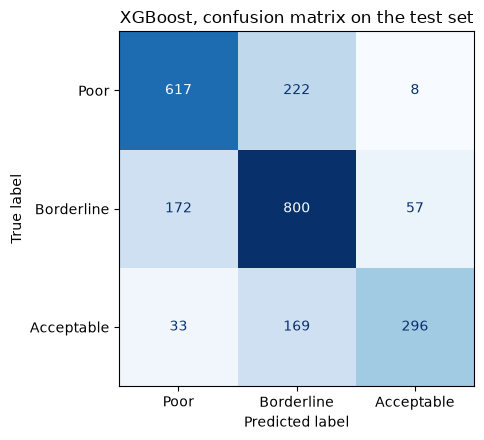

In [10]:
print(classification_report(y_test, pred_xgb))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_xgb, labels=CLASSES,
                                        cmap='Blues', ax=ax, colorbar=False)
ax.set_title('XGBoost, confusion matrix on the test set')
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', dpi=200)
plt.show()

## 9. Cross validation

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
xgb_cv = Pipeline([('prep', preprocessor),
                   ('model', XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.08,
                                           subsample=0.9, colsample_bytree=0.8,
                                           random_state=RANDOM_STATE, eval_metric='mlogloss'))])
scores = cross_val_score(xgb_cv, X, y.map(YMAP), cv=cv, scoring='accuracy', n_jobs=-1)
print('fold accuracies:', scores.round(3))
print('mean', round(scores.mean(), 3), '| standard deviation', round(scores.std(), 3))

fold accuracies: [0.728 0.727 0.725 0.737 0.734]
mean 0.73 | standard deviation 0.005


## 10. Permutation importance

Interpreted only now that the redundant variables have been removed. Reported as associations, not as a definitive ranking.

adm1_name                    18.13
tot_income                    3.37
ls_main                       1.47
hh_wealth_water               1.15
income_sec                    1.11
n_shocks                      1.04
crp_landsize_ha               1.03
income_main                   0.74
income_main_comp              0.60
shock_othereconomicshock      0.53
need_env_infra_rehab          0.51
shock_sicknessordeathofhh     0.49
need_crop_inputs              0.49
shock_pestoutbreak            0.45
hh_wealth_light               0.44
crp_irrig_source              0.43
ls_num_diff                   0.42
hh_education                  0.42
shock_higherfoodprices        0.40
hh_gender                     0.40
dtype: float64


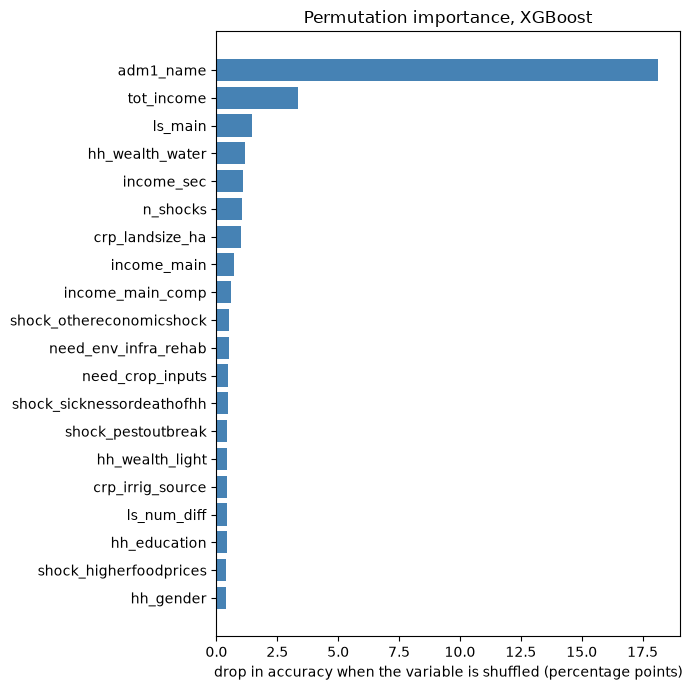

In [12]:
perm = permutation_importance(fitted['XGBoost'], X_test, y_test.map(YMAP),
                              n_repeats=5, random_state=RANDOM_STATE,
                              n_jobs=-1, scoring='accuracy')
perm_imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
print((perm_imp.head(20) * 100).round(2))

top20 = perm_imp.head(20).sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(top20.index, top20.values * 100, color='steelblue')
ax.set_xlabel('drop in accuracy when the variable is shuffled (percentage points)')
ax.set_title('Permutation importance, XGBoost')
plt.tight_layout()
plt.savefig('fig_permutation_importance.png', dpi=200)
plt.show()

## 11. SHAP values, the second and independent measure

In [13]:
prep_fitted = fitted['XGBoost'].named_steps['prep']
model_fitted = fitted['XGBoost'].named_steps['model']
X_test_encoded = prep_fitted.transform(X_test)
feature_names = prep_fitted.get_feature_names_out()

explainer = shap.TreeExplainer(model_fitted)
shap_values = np.array(explainer.shap_values(X_test_encoded))
mean_abs = np.abs(shap_values).mean(axis=0)
if mean_abs.ndim == 2:
    mean_abs = mean_abs.mean(axis=1)
shap_series = pd.Series(mean_abs, index=feature_names)

def to_original(name):
    name = name.split('__', 1)[1]
    for c in sorted(cat_cols, key=len, reverse=True):
        if name == c or name.startswith(c + '_'):
            return c
    return name

shap_grouped = shap_series.groupby(shap_series.index.map(to_original)).sum().sort_values(ascending=False)
print(shap_grouped.head(20).round(4))

adm1_name               0.8277
ls_main                 0.1633
tot_income              0.1510
income_sec              0.1285
income_main             0.1255
hh_wealth_water         0.1204
crp_irrig_source        0.0970
hh_wealth_light         0.0915
crp_landsize_ha         0.0873
income_main_comp        0.0844
n_shocks                0.0771
need_crop_inputs        0.0669
ls_num_diff             0.0623
need_env_infra_rehab    0.0569
hh_wealth_toilet        0.0464
hh_education            0.0422
crp_area_change         0.0419
need_crop_knowledge     0.0406
crp_main                0.0400
crp_harv_change         0.0399
dtype: float32


## 12. The pre-specified selection rule

Stated before the result is read, as the supervisor required.

**Rule.** The variables carried forward to the clustering are the twelve highest by mean rank across permutation importance and SHAP, after removing the redundant variables identified in section 5, and excluding province.

Province is excluded on a prior ground rather than because of its importance value: it describes the context a household lives in rather than a characteristic of the household itself, and the research question asks what household profiles exist. Where those profiles are concentrated geographically is then examined separately as a result, in notebook 03.

Twelve is chosen as a fixed number before inspecting the ranking, to keep the clustering interpretable while covering the variables that carry most of the signal.

In [14]:
K_VARIABLES = 12

ranking = pd.DataFrame({'permutation rank': perm_imp.rank(ascending=False),
                        'SHAP rank': shap_grouped.rank(ascending=False)}).dropna()
ranking['mean rank'] = ranking.mean(axis=1)
ranking = ranking.sort_values('mean rank')
print(ranking.head(20).round(1))
ranking.to_csv('results_variable_importance.csv')

selected = [v for v in ranking.index if v != 'adm1_name'][:K_VARIABLES]
print()
print('SELECTED BY THE RULE:')
for v in selected:
    print('   ', v)
pd.Series(selected).to_csv('top_variables.csv', index=False, header=['variable'])

                           permutation rank  SHAP rank  mean rank
adm1_name                               1.0        1.0        1.0
ls_main                                 3.0        2.0        2.5
tot_income                              2.0        3.0        2.5
income_sec                              5.0        4.0        4.5
hh_wealth_water                         4.0        6.0        5.0
income_main                             8.0        5.0        6.5
crp_landsize_ha                         7.0        9.0        8.0
n_shocks                                6.0       11.0        8.5
income_main_comp                        9.0       10.0        9.5
crp_irrig_source                       16.0        7.0       11.5
hh_wealth_light                        15.0        8.0       11.5
need_crop_inputs                       12.5       12.0       12.2
need_env_infra_rehab                   11.0       14.0       12.5
ls_num_diff                            17.0       13.0       15.0
shock_othe

## 13. Logistic regression coefficients

The third check, and the one that gives direction rather than only magnitude.

In [15]:
log_model = fitted['Logistic regression'].named_steps['model']
names = fitted['Logistic regression'].named_steps['prep'].get_feature_names_out()
poor_index = list(log_model.classes_).index('Poor')
coefs = pd.Series(log_model.coef_[poor_index], index=names).sort_values()

print('TEN STRONGEST TOWARDS POOR')
print(coefs.tail(10).round(3))
print()
print('TEN STRONGEST AWAY FROM POOR')
print(coefs.head(10).round(3))

TEN STRONGEST TOWARDS POOR
cat__adm1_name_Baghlan                                    0.699
cat__crp_main_Onions                                      0.807
cat__adm1_name_Khost                                      0.890
cat__adm1_name_Daykundi                                   1.031
cat__adm1_name_Samangan                                   1.072
cat__ls_main_Other                                        1.118
cat__income_main_Income not derived from work, charity    1.159
cat__adm1_name_Bamyan                                     1.365
cat__adm1_name_Ghor                                       1.663
cat__adm1_name_Balkh                                      1.770
dtype: float64

TEN STRONGEST AWAY FROM POOR
cat__adm1_name_Faryab                                 -1.645
cat__adm1_name_Kandahar                               -1.540
cat__adm1_name_Uruzgan                                -1.510
cat__adm1_name_Hilmand                                -1.297
cat__adm1_name_Hirat                        

## 14. How much of the performance comes from geography?

In [16]:
def quick_model(X_subset, label):
    cats = [c for c in X_subset.columns if not pd.api.types.is_numeric_dtype(X_subset[c])]
    nums = [c for c in X_subset.columns if c not in cats]
    Xtr, Xte, ytr, yte = train_test_split(X_subset, y, test_size=0.25,
                                          random_state=RANDOM_STATE, stratify=y)
    p = Pipeline([('prep', ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cats),
                                              ('num', StandardScaler(), nums)])),
                  ('model', XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.08,
                                          subsample=0.9, colsample_bytree=0.8,
                                          random_state=RANDOM_STATE, eval_metric='mlogloss'))])
    p.fit(Xtr, ytr.map(YMAP))
    pred = pd.Series(p.predict(Xte)).map(INV).values
    print(label, '-> accuracy', round(accuracy_score(yte, pred), 3),
          '| macro F1', round(f1_score(yte, pred, average='macro'), 3))

quick_model(X, 'all predictors   ')
quick_model(X.drop(columns=['adm1_name']), 'without province ')
quick_model(X[['adm1_name']], 'province only    ')

share_poor = (df.groupby('adm1_name')['fcg'].apply(lambda s: (s == 'Poor').mean() * 100)
                .sort_values(ascending=False))
print()
print('Share of Poor households by province')
print(share_poor.round(1).to_string())

all predictors    -> accuracy 0.722 | macro F1 0.716
without province  -> accuracy 0.671 | macro F1 0.661
province only     -> accuracy 0.572 | macro F1 0.543

Share of Poor households by province
adm1_name
Ghor              74.3
Balkh             73.6
Bamyan            67.5
Daykundi          65.3
Laghman           65.0
Khost             61.1
Kunduz            59.1
Not applicable    53.8
Samangan          48.6
Nangarhar         46.2
Paktika           46.2
Baghlan           44.6
Paktya            44.4
Nimroz            43.4
Takhar            39.2
Sar-e-Pul         34.8
Jawzjan           34.3
Badakhshan        34.1
Ghazni            32.5
Badghis           32.2
Farah             29.8
Kapisa            29.4
Kabul             25.1
Parwan            23.4
Uruzgan           20.9
Maidan Wardak     19.6
Zabul             15.6
Faryab            15.1
Nuristan          14.9
Kunar             12.6
Hilmand           12.5
Panjsher          11.2
Hirat             11.1
Kandahar           9.0
Logar      

## 15. Performance within each class

The three classes are not equally common, so overall accuracy can hide weak performance on the smaller classes. This section reports precision and recall for each class, and the macro F1, which gives the three classes equal weight, for all three models. Precision is the share of households predicted in a class that truly belong to it. Recall is the share of households in a class that the model finds.

In [17]:
from sklearn.metrics import precision_score, recall_score

print('share of each class in the test set (%):', (y_test.value_counts(normalize=True) * 100).round(1).to_dict())
print()
rows = []
for name, pred in [('Logistic regression', pred_log), ('Random forest', pred_rf), ('XGBoost', pred_xgb)]:
    precision = precision_score(y_test, pred, labels=CLASSES, average=None)
    recall = recall_score(y_test, pred, labels=CLASSES, average=None)
    row = {'model': name}
    for c, p, r in zip(CLASSES, precision, recall):
        row[c + ' precision'] = p
        row[c + ' recall'] = r
    row['macro F1'] = f1_score(y_test, pred, average='macro')
    rows.append(row)
per_class = pd.DataFrame(rows).set_index('model').round(3)
print(per_class.T.to_string())
per_class.to_csv('results_per_class.csv')

share of each class in the test set (%): {'Borderline': 43.3, 'Poor': 35.7, 'Acceptable': 21.0}

model                 Logistic regression  Random forest  XGBoost
Poor precision                      0.660          0.705    0.751
Poor recall                         0.660          0.752    0.728
Borderline precision                0.650          0.690    0.672
Borderline recall                   0.573          0.635    0.777
Acceptable precision                0.535          0.639    0.820
Acceptable recall                   0.665          0.671    0.594
macro F1                            0.621          0.681    0.716


**What the result shows.** No class is neglected. For XGBoost, the best model, recall is 0.73 for Poor, 0.78 for Borderline and 0.59 for Acceptable, and macro F1 is 0.716, close to the overall accuracy of 0.722. Acceptable, the smallest class, is the hardest to recognise: the model misses about four in ten Acceptable households, mostly by placing them in Borderline, but when it predicts Acceptable it is right more than eight times in ten. For targeting, the Poor class matters most: XGBoost finds 73 percent of Poor households, and three in four households it predicts as Poor are Poor. Logistic regression, with balanced class weights, finds more Acceptable households but with far more false alarms, which is why its macro F1 is lower.

## 16. Hyperparameters and the test set

The hyperparameters used above were fixed before the analysis and were not tuned, so the test set has only been used for the final evaluation. This section checks whether tuning would change the picture. The search uses five fold cross validation on the training set only, and the test set is used once at the end. The grid includes the settings used above, so the two can be compared directly. This cell takes several minutes.

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {'model__max_depth': [3, 5, 7],
              'model__learning_rate': [0.05, 0.08, 0.1],
              'model__n_estimators': [200, 400]}
search = GridSearchCV(
    Pipeline([('prep', preprocessor),
              ('model', XGBClassifier(subsample=0.9, colsample_bytree=0.8,
                                      random_state=RANDOM_STATE, eval_metric='mlogloss'))]),
    param_grid, scoring='accuracy', n_jobs=-1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE))
search.fit(X_train, y_train.map(YMAP))

grid = pd.DataFrame(search.cv_results_)[['param_model__max_depth', 'param_model__learning_rate',
                                          'param_model__n_estimators', 'mean_test_score', 'std_test_score']]
grid.columns = ['max depth', 'learning rate', 'trees', 'mean accuracy', 'standard deviation']
grid = grid.sort_values('mean accuracy', ascending=False)
print(grid.head(5).round(3).to_string(index=False))
grid.round(3).to_csv('results_tuning.csv', index=False)

fixed = grid[(grid['max depth'] == 5) & (grid['learning rate'] == 0.08) & (grid['trees'] == 400)]
print()
print('settings used in the thesis, cross validated accuracy on the training set:', round(float(fixed['mean accuracy'].iloc[0]), 3))
print('best settings, cross validated accuracy on the training set:', round(search.best_score_, 3), search.best_params_)

tuned_pred = pd.Series(search.predict(X_test)).map(INV).values
print('best settings on the test set: accuracy', round(accuracy_score(y_test, tuned_pred), 3),
      '| macro F1', round(f1_score(y_test, tuned_pred, average='macro'), 3))

 max depth  learning rate  trees  mean accuracy  standard deviation
         7           0.10    200          0.728               0.007
         7           0.08    200          0.726               0.008
         5           0.08    400          0.726               0.006
         7           0.10    400          0.726               0.008
         5           0.10    400          0.725               0.008

settings used in the thesis, cross validated accuracy on the training set: 0.726
best settings, cross validated accuracy on the training set: 0.728 {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 200}
best settings on the test set: accuracy 0.718 | macro F1 0.713


## 17. Robustness of the province variable

Province has 34 categories, far more than any other predictor, so two checks are added.

The first replaces the 34 provinces with the eight regions commonly used by humanitarian agencies in Afghanistan. If most of the geographic signal survives with this much coarser variable, the result does not depend on the model learning from small provincial samples.

The second ranks the household variables in a model without province and compares them with the twelve selected in section 12. If the same variables stay near the top, the selection does not depend on how the model shares information between province and the household variables.

In [19]:
REGIONS = {
    'Kabul': 'Central', 'Kapisa': 'Central', 'Logar': 'Central', 'Maidan Wardak': 'Central',
    'Panjsher': 'Central', 'Parwan': 'Central',
    'Bamyan': 'Central Highlands', 'Daykundi': 'Central Highlands',
    'Kunar': 'East', 'Laghman': 'East', 'Nangarhar': 'East', 'Nuristan': 'East',
    'Balkh': 'North', 'Faryab': 'North', 'Jawzjan': 'North', 'Samangan': 'North', 'Sar-e-Pul': 'North',
    'Badakhshan': 'North East', 'Baghlan': 'North East', 'Kunduz': 'North East', 'Takhar': 'North East',
    'Hilmand': 'South', 'Kandahar': 'South', 'Nimroz': 'South', 'Uruzgan': 'South', 'Zabul': 'South',
    'Ghazni': 'South East', 'Khost': 'South East', 'Paktika': 'South East', 'Paktya': 'South East',
    'Badghis': 'West', 'Farah': 'West', 'Ghor': 'West', 'Hirat': 'West',
}
print('provinces without a region:', sorted(set(X['adm1_name']) - set(REGIONS)))
X_region = X.drop(columns=['adm1_name']).assign(region=X['adm1_name'].map(REGIONS).fillna('Not applicable'))
quick_model(X, 'province, 34 categories')
quick_model(X_region, 'region, 8 categories   ')
quick_model(X.drop(columns=['adm1_name']), 'no geography           ')

provinces without a region: ['Not applicable']
province, 34 categories -> accuracy 0.722 | macro F1 0.716
region, 8 categories    -> accuracy 0.693 | macro F1 0.685
no geography            -> accuracy 0.671 | macro F1 0.661


In [20]:
X_np = X.drop(columns=['adm1_name'])
cats_np = [c for c in X_np.columns if not pd.api.types.is_numeric_dtype(X_np[c])]
nums_np = [c for c in X_np.columns if c not in cats_np]
Xtr_np, Xte_np, ytr_np, yte_np = train_test_split(X_np, y, test_size=0.25,
                                                  random_state=RANDOM_STATE, stratify=y)
model_np = Pipeline([
    ('prep', ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cats_np),
                                ('num', StandardScaler(), nums_np)])),
    ('model', XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.08, subsample=0.9,
                            colsample_bytree=0.8, random_state=RANDOM_STATE, eval_metric='mlogloss'))])
model_np.fit(Xtr_np, ytr_np.map(YMAP))
perm_np = permutation_importance(model_np, Xte_np, yte_np.map(YMAP), n_repeats=5,
                                 random_state=RANDOM_STATE, n_jobs=-1, scoring='accuracy')
rank_np = pd.Series(perm_np.importances_mean, index=Xte_np.columns).rank(ascending=False)
top_np = list(rank_np.sort_values().index[:12])

print('twelve most important household variables in the model without province:')
for v in top_np:
    print('   ', v, '| selected in section 12' if v in selected else '')
print()
print('overlap with the twelve selected by the rule:', len(set(top_np) & set(selected)), 'of 12')
print('rank of each selected variable without province:')
print(rank_np.loc[selected].astype(int).to_string())

twelve most important household variables in the model without province:
    tot_income | selected in section 12
    hh_wealth_water | selected in section 12
    n_shocks | selected in section 12
    crp_irrig_source | selected in section 12
    ls_main | selected in section 12
    hh_wealth_light | selected in section 12
    income_sec | selected in section 12
    income_main | selected in section 12
    shock_coldtemporhail 
    shock_sicknessordeathofhh 
    crp_landsize_ha | selected in section 12
    need_crop_inputs | selected in section 12

overlap with the twelve selected by the rule: 10 of 12
rank of each selected variable without province:
ls_main                  5
tot_income               1
income_sec               7
hh_wealth_water          2
income_main              8
crp_landsize_ha         11
n_shocks                 3
income_main_comp        16
crp_irrig_source         4
hh_wealth_light          6
need_crop_inputs        12
need_env_infra_rehab    25


**What the result shows.** Replacing the 34 provinces with 8 regions keeps a large part of the geographic signal: the accuracy with regions lies between the model with provinces and the model without any geography. The predictive power of geography therefore does not depend only on the fine provincial detail. Without province, most of the twelve variables selected in section 12 remain among the twelve most important, and the strongest of them, total income, main livestock type, drinking water source and second income source, stay at the top. The selection is therefore largely the same with or without province in the model.

## 18. Weighted share of Poor households by province

The shares in section 14 describe the households interviewed. This version uses the survey weights, so it describes the rural population of each province.

In [21]:
weighted_poor = df.groupby('adm1_name').apply(
    lambda g: g.loc[g['fcg'] == 'Poor', 'weight_final'].sum() / g['weight_final'].sum() * 100)
province_table = pd.DataFrame({'unweighted Poor %': share_poor, 'weighted Poor %': weighted_poor}).round(1)
print(province_table.sort_values('weighted Poor %', ascending=False).to_string())
print()
print('rank correlation between the two columns:', round(province_table.corr(method='spearman').iloc[0, 1], 3))

                unweighted Poor %  weighted Poor %
adm1_name                                         
Ghor                         74.3             76.4
Not applicable               53.8             71.0
Bamyan                       67.5             66.3
Laghman                      65.0             62.7
Balkh                        73.6             62.5
Khost                        61.1             61.0
Daykundi                     65.3             60.6
Kunduz                       59.1             60.2
Nimroz                       43.4             47.1
Paktika                      46.2             46.9
Nangarhar                    46.2             46.6
Baghlan                      44.6             44.2
Paktya                       44.4             38.3
Badakhshan                   34.1             37.0
Sar-e-Pul                    34.8             36.2
Jawzjan                      34.3             36.1
Takhar                       39.2             33.5
Farah                        29

**What the result shows.** The weighted and unweighted provincial shares are very close, with a rank correlation of 0.96, and the same provinces are at the top (Ghor, Bamyan, Laghman, Balkh, Khost and Daykundi) and at the bottom (Logar, Hirat, Hilmand, Panjsher and Kunar). A few provinces move more, for example Samangan, from 48.6 to 31.5 percent, and Kandahar, from 9.0 to 19.7 percent, so the weighted figures are used when individual provinces are described.